In [1]:
import numpy as np
import matplotlib.pylab as plt

import uproot
import awkward as ak

Find a file in an open data dataset https://opendata.cern.ch/record/30555

In [2]:
cms_file = 'root://eospublic.cern.ch//eos/opendata/cms/Run2016H/DoubleMuon/NANOAOD/UL2016_MiniAODv2_NanoAODv9-v1/2510000/127C2975-1B1C-A046-AABF-62B77E757A86.root'

In [3]:
cms_infile = uproot.open(cms_file)
cms_events = cms_infile['Events']

Read the variables from https://opendata.cern.ch/eos/opendata/cms/dataset-semantics/NanoAOD/30555/DoubleMuon_doc.html#Muon

In [4]:
print(cms_events['Muon_pt'].array())

[[], [16], [38.3, 37.8], ..., [97.8, ...], [48.3, 35.9], [13.8, 10.3, 8.87]]


This is an array of arrays. Each event can have different number of muons, for example:

In [5]:
print(cms_events['Muon_pt'].array()[3])

[42.9, 27.3]


Check the number of events in this file:

In [6]:
len(cms_events['Muon_pt'].array())

2147195

Define a function to compute the invariant mass using the available variables: transverse momentum (pt), pseudorapidity (eta) and angle phi

In [7]:
def invariant_mass(pt1, pt2, eta1, eta2, phi1, phi2, m1, m2):
    # Total momentum using pt and pseudorapidity (eta)
    p1 = pt1 * np.cosh(eta1)  
    p2 = pt2 * np.cosh(eta2)
    # Energy
    E1 = np.sqrt(p1**2 + m1**2)
    E2 = np.sqrt(p2**2 + m2**2)
    # Momentum components
    px1, py1, pz1 = pt1 * np.cos(phi1), pt1 * np.sin(phi1), pt1 * np.sinh(eta1)
    px2, py2, pz2 = pt2 * np.cos(phi2), pt2 * np.sin(phi2), pt2 * np.sinh(eta2)
    
    return np.sqrt((E1 + E2)**2 - (px1 + px2)**2 - (py1 + py2)**2 - (pz1 + pz2)**2)

Select those collision events in which there are at least two muons and take the needed values of the two first

In [8]:
nMuon = cms_events['nMuon'].array()
pt1, pt2 = cms_events['Muon_pt'].array()[nMuon >= 2][:, 0], cms_events['Muon_pt'].array()[nMuon >= 2][:, 1]
eta1, eta2 = cms_events['Muon_eta'].array()[nMuon >= 2][:, 0], cms_events['Muon_eta'].array()[nMuon >= 2][:, 1]
phi1, phi2 = cms_events['Muon_phi'].array()[nMuon >= 2][:, 0], cms_events['Muon_phi'].array()[nMuon >= 2][:, 1]
m1, m2 = cms_events['Muon_mass'].array()[nMuon >= 2][:, 0], cms_events['Muon_mass'].array()[nMuon >= 2][:, 1]

Compute the invariant mass using the function above:

In [9]:
inv_mass = invariant_mass(pt1, pt2, eta1, eta2, phi1, phi2, m1, m2)

/home/kati/.local/lib/python3.10/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in sqrt
  return impl(*broadcasted_args, **(kwargs or {}))


Plot the value:

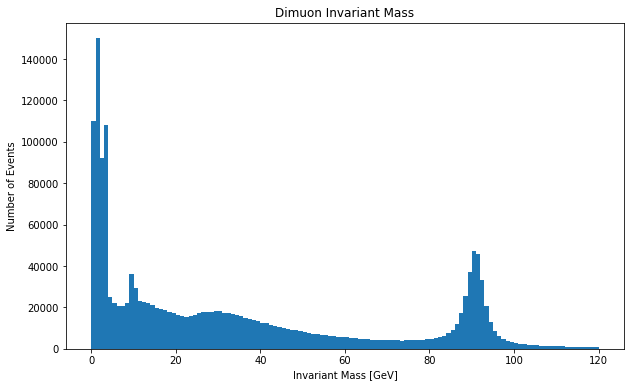

In [10]:
plt.figure(figsize=(10, 6))
plt.hist(inv_mass, bins=120, range=(0,120))
plt.xlabel('Invariant Mass [GeV]')
plt.ylabel('Number of Events')
plt.title('Dimuon Invariant Mass')
plt.show()